<a href="https://colab.research.google.com/github/eppursimuove9/alura-store/blob/main/alura-store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [40]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



## Calcular el ingreso total facturación para cada tienda

In [41]:
ingresos_tienda_1 = tienda['Precio'].sum()
ingresos_tienda_2 = tienda2['Precio'].sum()
ingresos_tienda_3 = tienda3['Precio'].sum()
ingresos_tienda_4 = tienda4['Precio'].sum()

In [42]:
print(f"Ingreso Total Tienda 1: ${ingresos_tienda_1:,.2f}")
print(f"Ingreso Total Tienda 2: ${ingresos_tienda_2:,.2f}")
print(f"Ingreso Total Tienda 3: ${ingresos_tienda_3:,.2f}")
print(f"Ingreso Total Tienda 4: ${ingresos_tienda_4:,.2f}")

Ingreso Total Tienda 1: $1,150,880,400.00
Ingreso Total Tienda 2: $1,116,343,500.00
Ingreso Total Tienda 3: $1,098,019,600.00
Ingreso Total Tienda 4: $1,038,375,700.00


###DataFrame para resumir los ingresos

In [43]:

data_ingresos = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso_Total': [ingresos_tienda_1, ingresos_tienda_2, ingresos_tienda_3, ingresos_tienda_4]
}

df_ingresos = pd.DataFrame(data_ingresos)
df_ingresos = df_ingresos.sort_values(by='Ingreso_Total', ascending=False)

print("Resumen de Ingresos por Tienda:")
df_ingresos

Resumen de Ingresos por Tienda:


,Tienda,Ingreso_Total
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09


# 2. Ventas por categoría

##Calcular la cantidad de ventas por categoría para cada tienda

In [44]:
print("--- Ventas por Categoría - Tienda 1 ---")
ventas_categoria_1 = tienda['Categoría del Producto'].value_counts()
print(ventas_categoria_1.to_string())
print("\n" + "="*20 + "\n")

print("--- Ventas por Categoría - Tienda 2 ---")
ventas_categoria_2 = tienda2['Categoría del Producto'].value_counts()
print(ventas_categoria_2.to_string())
print("\n" + "="*20 + "\n")

print("--- Ventas por Categoría - Tienda 3 ---")
ventas_categoria_3 = tienda3['Categoría del Producto'].value_counts()
print(ventas_categoria_3.to_string())
print("\n" + "="*20 + "\n")

print("--- Ventas por Categoría - Tienda 4 ---")
ventas_categoria_4 = tienda4['Categoría del Producto'].value_counts()
print(ventas_categoria_4.to_string())

--- Ventas por Categoría - Tienda 1 ---
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171


--- Ventas por Categoría - Tienda 2 ---
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181


--- Ventas por Categoría - Tienda 3 ---
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177


--- Ventas por Categoría - Tienda 4 ---
Categoría del Product

##DataFrame consolidado para comparar las ventas por categoría

In [45]:
"""
Construcción de un resumen consolidado de ventas por categoría.
Cada serie de ventas por tienda se transforma en un DataFrame,
luego se combinan todas las tiendas alineando las categorías.
Finalmente se reemplazan valores faltantes por 0 para obtener
una tabla completa de comparación entre tiendas.
"""

# Convertir cada Serie de conteo en un DataFrame individual
# asignando un nombre específico a la columna de cada tienda
df_ventas_cat_1 = ventas_categoria_1.to_frame(name='Ventas_Tienda_1')
df_ventas_cat_2 = ventas_categoria_2.to_frame(name='Ventas_Tienda_2')
df_ventas_cat_3 = ventas_categoria_3.to_frame(name='Ventas_Tienda_3')
df_ventas_cat_4 = ventas_categoria_4.to_frame(name='Ventas_Tienda_4')

# Unir todos los DataFrames en una sola tabla,
# colocando cada tienda como una columna y alineando las categorías
df_ventas_categorias_total = pd.concat(
    [df_ventas_cat_1, df_ventas_cat_2, df_ventas_cat_3, df_ventas_cat_4],
    axis=1
)

# Sustituir valores faltantes (categorías sin ventas en alguna tienda) por 0
# y asegurar que los datos finales sean enteros
df_ventas_categorias_total = df_ventas_categorias_total.fillna(0).astype(int)

print("Resumen Consolidado de Ventas por Categoría:")
df_ventas_categorias_total

Resumen Consolidado de Ventas por Categoría:


,Ventas_Tienda_1,Ventas_Tienda_2,Ventas_Tienda_3,Ventas_Tienda_4
Categoría del Producto,,,,
Muebles,465,442,499,480
Electrónicos,448,422,451,451
Juguetes,324,313,315,338
Electrodomésticos,312,305,278,254
Deportes y diversión,284,275,277,277
Instrumentos musicales,182,224,177,170
Libros,173,197,185,187
Artículos para el hogar,171,181,177,201


# 3. Calificación promedio de la tienda


##Calcular la calificación promedio para cada tienda

In [46]:
calificacion_tienda_1 = tienda['Calificación'].mean()
calificacion_tienda_2 = tienda2['Calificación'].mean()
calificacion_tienda_3 = tienda3['Calificación'].mean()
calificacion_tienda_4 = tienda4['Calificación'].mean()

##DataFrame para resumir las calificaciones

In [47]:
# Guardar las calificaciones promedio de cada tienda en un diccionario
calificaciones = {
    "Tienda 1": calificacion_tienda_1,
    "Tienda 2": calificacion_tienda_2,
    "Tienda 3": calificacion_tienda_3,
    "Tienda 4": calificacion_tienda_4
}

# Recorrer el diccionario e imprimir cada resultado
for nombre_tienda, calificacion in calificaciones.items():
    print(f"Promedio de calificación - {nombre_tienda}: {calificacion:.2f} estrellas")

Promedio de calificación - Tienda 1: 3.98 estrellas
Promedio de calificación - Tienda 2: 4.04 estrellas
Promedio de calificación - Tienda 3: 4.05 estrellas
Promedio de calificación - Tienda 4: 4.00 estrellas


In [48]:
# Crear una estructura de datos con el nombre de cada tienda y su calificación promedio
data_calificaciones = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Calificacion_Promedio': [calificacion_tienda_1, calificacion_tienda_2, calificacion_tienda_3, calificacion_tienda_4]
}

# Convertir el diccionario en un DataFrame para facilitar el análisis y visualización
df_calificaciones = pd.DataFrame(data_calificaciones)

# Ordenar las tiendas de mayor a menor según su calificación promedio
df_calificaciones = df_calificaciones.sort_values(by='Calificacion_Promedio', ascending=False)

print("Detalle de las Calificaciones Promedio por Tienda:")
df_calificaciones

Detalle de las Calificaciones Promedio por Tienda:


,Tienda,Calificacion_Promedio
2,Tienda 3,4.048326
1,Tienda 2,4.037304
3,Tienda 4,3.995759
0,Tienda 1,3.976685


# 4. Productos más y menos vendidos

##Contar las ventas de cada producto en cada tienda

In [49]:
# Calcular ventas por producto en cada tienda
ventas_por_producto_1 = tienda['Producto'].value_counts()
ventas_por_producto_2 = tienda2['Producto'].value_counts()
ventas_por_producto_3 = tienda3['Producto'].value_counts()
ventas_por_producto_4 = tienda4['Producto'].value_counts()

# Agrupar las series en un diccionario para recorrerlas fácilmente
ventas_tiendas = {
    "Tienda 1": ventas_por_producto_1,
    "Tienda 2": ventas_por_producto_2,
    "Tienda 3": ventas_por_producto_3,
    "Tienda 4": ventas_por_producto_4
}

# --- 5 Más vendidos ---
print("--- Productos Más vendidos ---")
for nombre_tienda, ventas in ventas_tiendas.items():
    print(f"\n-- {nombre_tienda} --")
    print(ventas.head(5).to_string())

print("\n" + "="*40 + "\n")

# --- 5 Menos vendidos ---
print("Productos Menos Vendidos")
for nombre_tienda, ventas in ventas_tiendas.items():
    print(f"\n-- {nombre_tienda} --")
    print(ventas.tail(5).to_string())

--- Productos Más vendidos ---

-- Tienda 1 --
Producto
Microondas          60
TV LED UHD 4K       60
Armario             60
Secadora de ropa    58
Mesa de noche       56

-- Tienda 2 --
Producto
Iniciando en programación    65
Microondas                   62
Batería                      61
Guitarra acústica            58
Pandereta                    58

-- Tienda 3 --
Producto
Kit de bancas      57
Mesa de comedor    56
Cama king          56
Set de ollas       55
Mesa de noche      55

-- Tienda 4 --
Producto
Cama box                     62
Cubertería                   59
Dashboards con Power BI      56
Cama king                    56
Carrito de control remoto    55


Productos Menos Vendidos

-- Tienda 1 --
Producto
Ciencia de datos con Python    39
Pandereta                      36
Olla de presión                35
Auriculares con micrófono      33
Celular ABXY                   33

-- Tienda 2 --
Producto
Auriculares        37
Sillón             35
Mesa de comedor    34
Impresora  

# 5. Envío promedio por tienda

##Calcular el costo de envío promedio para cada tienda

In [50]:
envio_promedio_tienda_1 = tienda['Costo de envío'].mean()
envio_promedio_tienda_2 = tienda2['Costo de envío'].mean()
envio_promedio_tienda_3 = tienda3['Costo de envío'].mean()
envio_promedio_tienda_4 = tienda4['Costo de envío'].mean()

In [51]:
# Guardar los costos de envío promedio por tienda
envios_promedio = {
    "Tienda 1": envio_promedio_tienda_1,
    "Tienda 2": envio_promedio_tienda_2,
    "Tienda 3": envio_promedio_tienda_3,
    "Tienda 4": envio_promedio_tienda_4
}

# Mostrar resultados
for nombre_tienda, costo in envios_promedio.items():
    print(f"Costo de envío promedio - {nombre_tienda}: ${costo:,.2f}")

Costo de envío promedio - Tienda 1: $26,018.61
Costo de envío promedio - Tienda 2: $25,216.24
Costo de envío promedio - Tienda 3: $24,805.68
Costo de envío promedio - Tienda 4: $23,459.46


##DataFrame para resumir los costos de envío

In [52]:
envios_promedio = {
    "Tienda 1": envio_promedio_tienda_1,
    "Tienda 2": envio_promedio_tienda_2,
    "Tienda 3": envio_promedio_tienda_3,
    "Tienda 4": envio_promedio_tienda_4
}

df_envios = (
    pd.DataFrame(envios_promedio.items(), columns=['Tienda', 'Costo_Promedio_Envio'])
    .sort_values('Costo_Promedio_Envio')
)

print("Resumen Costo de Envío Promedio por Tienda (de menor a mayor):")
df_envios

Resumen Costo de Envío Promedio por Tienda (de menor a mayor):


,Tienda,Costo_Promedio_Envio
3,Tienda 4,23459.457167
2,Tienda 3,24805.680373
1,Tienda 2,25216.235693
0,Tienda 1,26018.609580


# 6. Generando Gráficos

##Ingresos Totales por Tienda

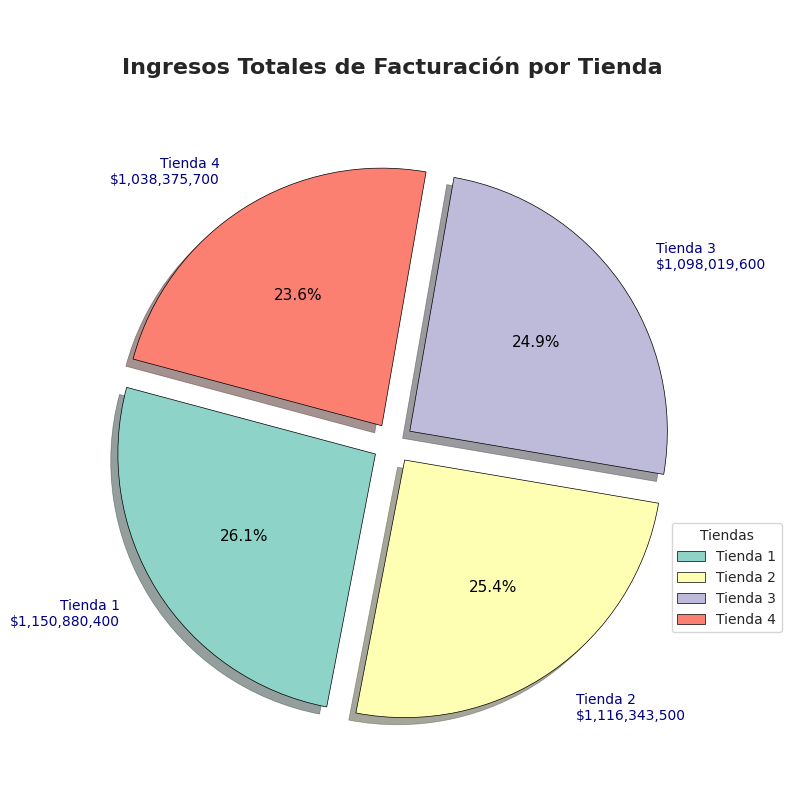

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Ordenar el DataFrame por ingreso total
df_ingresos = df_ingresos.sort_values(by='Ingreso_Total', ascending=False)

# Extraer etiquetas y valores desde el DataFrame existente
labels = df_ingresos['Tienda']
sizes = df_ingresos['Ingreso_Total']

# Función para formatear valores en dinero
def custom_format(value):
    return f"${value:,.0f}"

# Colores y separación de las porciones
colors = plt.cm.Set3.colors
explode = [0.08] * len(labels)

# Crear figura
fig, ax = plt.subplots(figsize=(8, 8))

# Crear gráfico de torta
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    autopct='%1.1f%%',
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5},
    explode=explode,
    colors=colors,
    startangle=165,
    shadow=True,
    textprops=dict(color='black', fontsize=11)
)

# Agregar etiquetas externas con tienda + ingreso
for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2.0
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))
    ha = "left" if x > 0 else "right"

    ax.text(
        x * 1.25, y * 1.25,
        f"{labels.iloc[i]}\n{custom_format(sizes.iloc[i])}",
        ha=ha, va='center', color='navy', fontsize=10
    )

# Leyenda
ax.legend(wedges, labels, title="Tiendas", loc="center left", bbox_to_anchor=(0.95, -0.2, 0.5, 1))

# Título
plt.title("\n\nIngresos Totales de Facturación por Tienda\n", fontsize=16, fontweight='bold')

plt.axis('equal')
plt.tight_layout()

plt.savefig('ingresos_totales_facturacion_por_tienda.png', dpi=300, bbox_inches='tight')

plt.show()

##2. Distribución de Ventas por Categoría

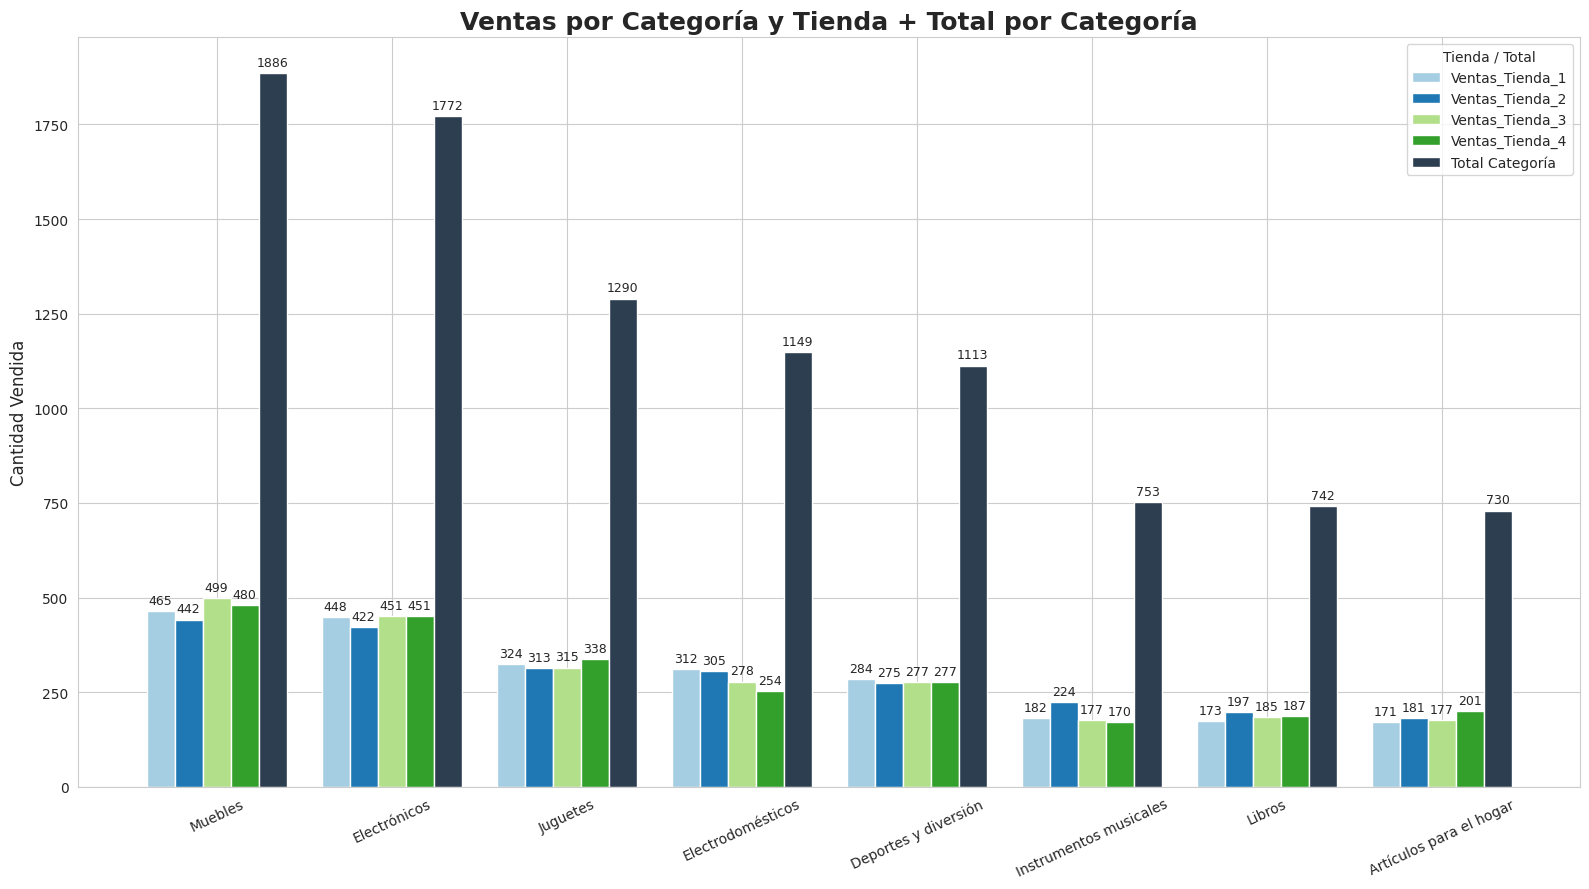

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

# calcular total por categoría
df_plot = df_ventas_categorias_total.copy()
df_plot["Total Categoría"] = df_plot.sum(axis=1)

categorias = df_plot.index
tiendas = df_plot.columns

x = np.arange(len(categorias))
width = 0.8 / len(tiendas)

fig, ax = plt.subplots(figsize=(16,9))

# colores para tiendas + total
colores = sns.color_palette('Paired', len(tiendas)-1)
colores.append("#2C3E50")  # color fuerte para TOTAL

for i, tienda in enumerate(tiendas):

    bars = ax.bar(
        x + (i - len(tiendas)/2)*width + width/2,
        df_plot[tienda],
        width,
        label=tienda,
        color=colores[i]
    )

    # valores sobre cada barra
    ax.bar_label(bars, padding=3, fontsize=9)

ax.set_title(
    "Ventas por Categoría y Tienda + Total por Categoría",
    fontsize=18,
    fontweight='bold'
)

ax.set_ylabel("Cantidad Vendida", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categorias, rotation=25)

ax.legend(title="Tienda / Total")

plt.tight_layout()

plt.savefig('ventas_por_categoria_y_tienda.png', dpi=300, bbox_inches='tight')

plt.show()

##3. Calificación Promedio vs. Costo de Envío

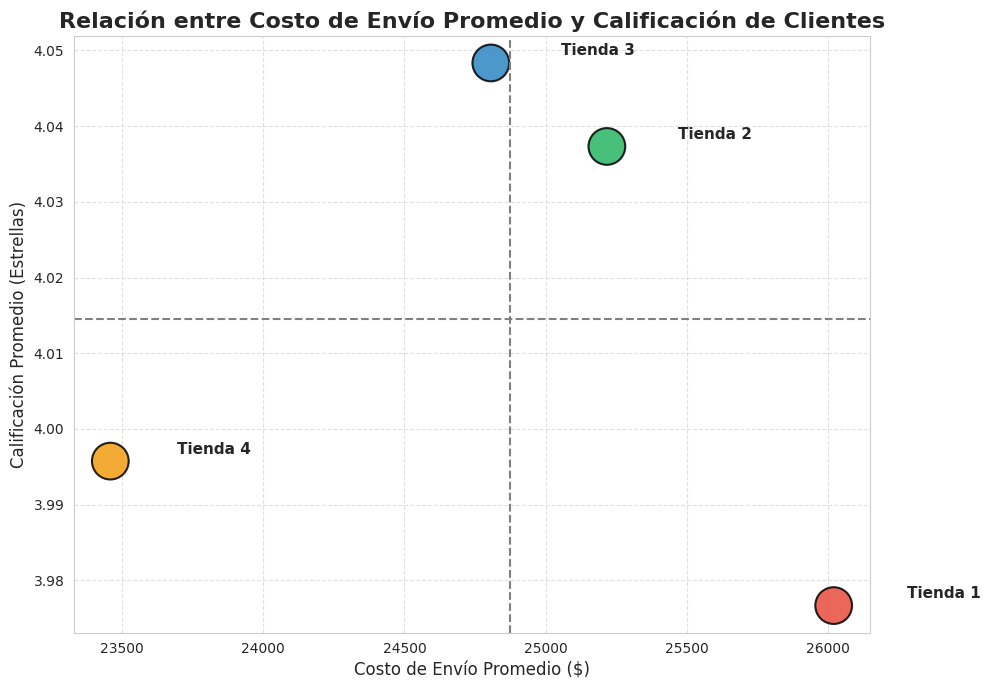

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df_metricas = pd.merge(df_calificaciones, df_envios, on='Tienda')

plt.figure(figsize=(10,7))

colores = ['#2E86C1','#28B463','#F39C12','#E74C3C']

plt.scatter(
    df_metricas['Costo_Promedio_Envio'],
    df_metricas['Calificacion_Promedio'],
    s=700,
    c=colores,
    alpha=0.85,
    edgecolors='black',
    linewidth=1.5
)

# Promedios para crear cuadrantes
x_prom = df_metricas['Costo_Promedio_Envio'].mean()
y_prom = df_metricas['Calificacion_Promedio'].mean()

plt.axvline(x=x_prom, linestyle='--', color='gray')
plt.axhline(y=y_prom, linestyle='--', color='gray')

# Etiquetas de cada tienda
for _, row in df_metricas.iterrows():
    plt.text(
        row['Costo_Promedio_Envio'] * 1.01,
        row['Calificacion_Promedio'] + 0.001,
        row['Tienda'],
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Relación entre Costo de Envío Promedio y Calificación de Clientes',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Costo de Envío Promedio ($)', fontsize=12)
plt.ylabel('Calificación Promedio (Estrellas)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('costo_envio_promedio_y_calificacion_cliente.png', dpi=300, bbox_inches='tight')


plt.show()

##4. Productos Más Vendidos por Cada Tienda

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

def graficar_top_5_interactivo(tienda_seleccionada):
    # 1. Filtramos la base de datos por la tienda seleccionada
    df_filtrado = df_completo[df_completo['Tienda'] == tienda_seleccionada]

    # 2. Recalculamos el Top 5 dinámicamente
    top_5 = df_filtrado['Producto'].value_counts().head(5).sort_values(ascending=True)

    # (Si tus ventas se suman por una columna 'Cantidad', usa esto en su lugar):
    # top_5 = df_filtrado.groupby('Producto')['Cantidad'].sum().nlargest(5).sort_values(ascending=True)

    plt.figure(figsize=(11,6))

    # Paleta degradada
    colores = sns.color_palette("Blues_r", len(top_5))

    barras = plt.barh(
        top_5.index,
        top_5.values,
        color=colores,
        edgecolor='black'
    )

    # Etiquetas dentro de las barras
    for i, barra in enumerate(barras):
        valor = barra.get_width()
        if valor > 0: # Evita errores si hay barras vacías
            plt.text(
                valor * 0.98,
                barra.get_y() + barra.get_height()/2,
                f'{int(valor)}',
                va='center',
                ha='right',
                fontsize=11,
                fontweight='bold',
                color='white'
            )

    # Título dinámico que cambia con el filtro
    plt.title(
        f'Top 5 Productos Más Vendidos — {tienda_seleccionada}',
        fontsize=16,
        fontweight='bold',
        pad=20
    )

    plt.xlabel('Cantidad Vendida', fontsize=12)
    plt.ylabel('Producto', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    sns.despine(left=True, bottom=True)

    plt.tight_layout()
    plt.show()

# 4. Obtenemos la lista limpia de todas tus tiendas
lista_tiendas = df_completo['Tienda'].dropna().unique().tolist()
lista_tiendas.sort() # Ordenamos alfabéticamente para que el menú se vea más profesional

# 5. Desplegamos el widget interactivo
interact(graficar_top_5_interactivo, tienda_seleccionada=widgets.Dropdown(
    options=lista_tiendas,
    value=lista_tiendas[0], # Valor por defecto
    description='Tienda:',
    disabled=False,
));

plt.savefig('productos_mas_vendidos_por_tienda.png', dpi=300, bbox_inches='tight')


interactive(children=(Dropdown(description='Tienda:', options=('Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4')…

<Figure size 640x480 with 0 Axes>

# INFORME DE ANÁLISIS DE DESEMPEÑO DE TIENDAS

**Cadena:** Alura Store  
**Preparado para:** Sr. Juan  
**Fecha:** Noviembre 2025  
**Asunto:** Evaluación de desempeño de las cuatro tiendas y recomendación estratégica de venta  

---

# 1. Introducción

El presente informe tiene como objetivo evaluar el desempeño operativo y comercial de las cuatro tiendas que componen la cadena **Alura Store**, con el fin de identificar cuál de ellas representa la mejor candidata para ser vendida.  

Esta decisión permitirá al Sr. Juan obtener capital para el desarrollo de su nuevo emprendimiento sin comprometer la estabilidad futura del negocio.

Para desarrollar este análisis se evaluaron cinco indicadores clave de desempeño:

- Ingresos Totales de Facturación  
- Distribución de Ventas por Categoría  
- Nivel de Satisfacción del Cliente  
- Productos Más y Menos Vendidos  
- Costo Promedio de Envío  

El análisis integrado de estos indicadores permite comprender no solo el rendimiento financiero actual de cada tienda, sino también su **sostenibilidad operativa y competitividad futura**.

---

# 2. Análisis de Desempeño

## 2.1 Ingresos Totales

El análisis de facturación permite identificar el aporte económico de cada tienda dentro de la cadena.

**Ingreso total por tienda:**

- Tienda 1: $1,150,880,400  
- Tienda 2: $1,116,343,500  
- Tienda 3: $1,098,019,600  
- Tienda 4: $1,038,375,700  

La **Tienda 1** presenta el mayor nivel de ingresos, seguida por las tiendas **2 y 3**, cuyos resultados son relativamente cercanos entre sí.

Por otro lado, la **Tienda 4** muestra el menor nivel de facturación dentro de la cadena.

Sin embargo, aunque la facturación es un indicador fundamental, **no necesariamente refleja la eficiencia operativa ni la sostenibilidad futura del negocio**, por lo que debe analizarse en conjunto con otras variables clave.

---

## 2.2 Distribución de Ventas por Categoría

El análisis de las ventas por categoría permite identificar los segmentos de productos con mayor rotación dentro de cada tienda.

De forma consistente en todas las tiendas, las categorías con mayor volumen de ventas son:

- Muebles  
- Electrónicos  
- Juguetes  
- Electrodomésticos  

Esto sugiere que el modelo de negocio de la cadena presenta una **estructura de demanda relativamente homogénea**, donde estas categorías concentran la mayor parte del movimiento comercial.

Las diferencias entre tiendas **no se explican principalmente por la categoría de productos**, sino más bien por factores operativos, logísticos y de experiencia del cliente.

---

## 2.3 Satisfacción del Cliente

La satisfacción del cliente se evaluó mediante el promedio de calificaciones otorgadas en las reseñas.

**Calificación promedio por tienda:**

- Tienda 1: 3.98 estrellas  
- Tienda 2: 4.04 estrellas  
- Tienda 3: 4.05 estrellas  
- Tienda 4: 4.00 estrellas  

Los resultados muestran que **todas las tiendas mantienen niveles de satisfacción relativamente positivos**, con calificaciones cercanas o superiores a 4 estrellas.

No obstante, la **Tienda 1 presenta la calificación promedio más baja dentro del grupo**.

Aunque la diferencia pueda parecer moderada, en entornos de **comercio digital y retail competitivo**, incluso pequeñas variaciones en la percepción del cliente pueden impactar significativamente en:

- la tasa de conversión  
- la recompra  
- la reputación de la marca  
- la captación de nuevos clientes  

Este indicador sugiere una **posible debilidad en la experiencia del cliente de la Tienda 1**.

---

## 2.4 Análisis de Productos

El análisis de productos permite identificar patrones de rotación dentro de cada tienda.

### Productos más vendidos

Entre los productos con mayor volumen de ventas destacan artículos relacionados con:

- Electrodomésticos (Microondas, Secadoras)  
- Electrónica (TV LED UHD 4K)  
- Muebles (Armarios, Camas, Mesas)  

Esto confirma que los **productos para el hogar y tecnología concentran gran parte de la demanda dentro de la cadena**.

### Productos menos vendidos

Los productos con menor rotación incluyen principalmente:

- libros especializados  
- instrumentos musicales  
- algunos dispositivos electrónicos específicos  

Estos productos presentan una **demanda más limitada**, lo que explica su menor volumen de ventas.

En términos generales, **no se observan diferencias estructurales significativas entre tiendas respecto al mix de productos**, lo que indica que el rendimiento depende más de la gestión operativa que del portafolio.

---

## 2.5 Costos Promedio de Envío

El costo de envío representa un factor crítico en la decisión de compra y en la satisfacción del cliente.

**Costo de envío promedio por tienda:**

- Tienda 1: $26,018.61  
- Tienda 2: $25,216.24  
- Tienda 3: $24,805.68  
- Tienda 4: $23,459.46  

Los datos muestran que la **Tienda 1 presenta el costo logístico más alto de toda la cadena**, mientras que la **Tienda 4 posee el menor costo promedio**.

Los costos logísticos elevados pueden impactar negativamente en:

- la competitividad de precios  
- la satisfacción del cliente  
- los márgenes de rentabilidad  
- la eficiencia operativa  

Este indicador refuerza la hipótesis de que la **Tienda 1 enfrenta desafíos logísticos que podrían afectar su desempeño futuro**.

---

# 3. Evaluación Estratégica Integrada

Al analizar conjuntamente los indicadores de ingresos, satisfacción del cliente y costos logísticos, se observa el siguiente patrón:

- **Tienda 3** presenta el mejor equilibrio entre ingresos, satisfacción del cliente y costos operativos.  
- **Tienda 2** mantiene un desempeño sólido y estable.  
- **Tienda 4**, aunque tiene menores ingresos, destaca por su eficiencia logística.  
- **Tienda 1**, pese a liderar en ingresos, presenta el menor nivel de satisfacción del cliente y los mayores costos logísticos.  

Este perfil sugiere que **la Tienda 1 podría estar experimentando ineficiencias operativas que, a largo plazo, podrían deteriorar su rendimiento financiero**.

---

# 4. Conclusión y Recomendación

Tras analizar los indicadores clave de desempeño, se concluye que **la Tienda 1 debería ser considerada como la principal candidata para la venta**.

## Justificación estratégica

### 1. Riesgo operativo creciente

La Tienda 1 presenta el **costo logístico más alto de toda la cadena**, lo cual afecta directamente la competitividad y los márgenes.

### 2. Menor satisfacción del cliente

Es la tienda con la **calificación promedio más baja**, lo que puede impactar negativamente en la fidelización y en las ventas futuras.

### 3. Oportunidad de maximizar el valor de venta

Debido a que actualmente es la tienda con **mayor facturación**, su valor de mercado probablemente sea elevado, lo que permitiría **obtener un mayor retorno en una posible transacción**.

---

# 5. Recomendación Final

Considerando todos los factores analizados, se recomienda que el Sr. Juan **proceda con la venta de la Tienda 1**.

Esta decisión permitiría:

- capitalizar el alto valor actual del activo  
- reducir la exposición a riesgos operativos futuros  
- concentrar la operación en las tiendas con mayor estabilidad y eficiencia  

De esta forma, el Sr. Juan podrá **obtener recursos para financiar su nuevo emprendimiento sin comprometer la solidez del resto de la cadena**.

# 7. Extra - Análisis Geográfico

##Top 10 Ciudades por Facturación - Ingresos por Tienda

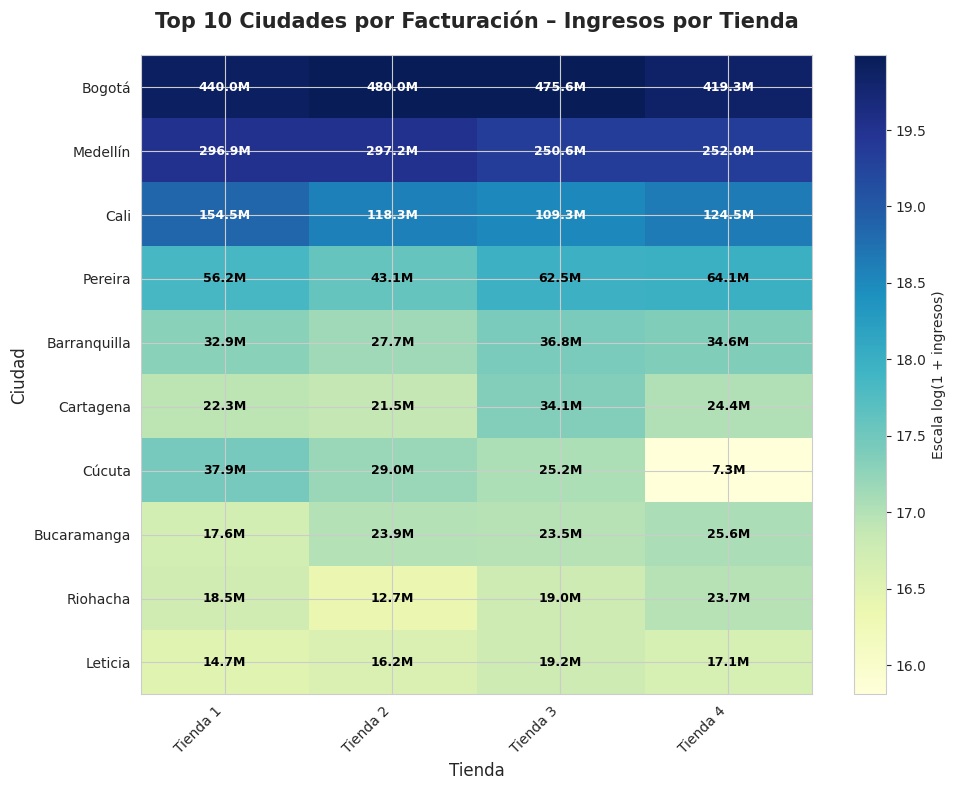

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1️⃣ Calcular facturación total por ciudad
facturacion_ciudad = (
    df_completo.groupby('Lugar de Compra')['Precio']
    .sum()
    .sort_values(ascending=False)
)

# 2️⃣ Seleccionar Top 10 ciudades
top10_ciudades = facturacion_ciudad.head(10).index

# 3️⃣ Crear tabla de ingresos por tienda en esas ciudades
tabla_top10 = (
    df_completo[df_completo['Lugar de Compra'].isin(top10_ciudades)]
    .pivot_table(
        index='Lugar de Compra',
        columns='Tienda',
        values='Precio',
        aggfunc='sum',
        fill_value=0
    )
)

# 4️⃣ Ordenar ciudades por volumen total de ventas
tabla_top10 = tabla_top10.loc[
    tabla_top10.sum(axis=1).sort_values(ascending=False).index
]

# 5️⃣ Crear heatmap
fig, ax = plt.subplots(figsize=(10, 8)) # Usamos subplots para mejor control

data_log = np.log1p(tabla_top10.values)
cmap_name = 'YlGnBu'
im = ax.imshow(
    data_log,
    cmap=cmap_name,  # paleta fresca
    aspect='auto'
)

ax.set_xticks(
    np.arange(tabla_top10.shape[1])
)
ax.set_xticklabels(
    tabla_top10.columns,
    fontsize=10,
    rotation=45, # Rotamos etiquetas para evitar solapamiento
    ha='right'
)

ax.set_yticks(
    np.arange(tabla_top10.shape[0])
)
ax.set_yticklabels(
    tabla_top10.index,
    fontsize=10
)

# 6️⃣ Agregar etiquetas de valores con color adaptativo (MEJORA AQUÍ)
# Obtenemos el colormap y la normalización para calcular la intensidad
cmap = plt.get_cmap(cmap_name)
norm = mcolors.Normalize(vmin=data_log.min(), vmax=data_log.max())

for i in range(tabla_top10.shape[0]):
    for j in range(tabla_top10.shape[1]):
        v = tabla_top10.values[i, j]
        v_log = data_log[i, j]

        # Determinar el color del texto basado en la intensidad del fondo
        # Calculamos la luminancia del color de fondo
        rgba_color = cmap(norm(v_log))
        luminance = (0.299 * rgba_color[0] + 0.587 * rgba_color[1] + 0.114 * rgba_color[2])

        # Si es oscuro (<0.5), usar texto blanco; si es claro, usar negro
        text_color = 'white' if luminance < 0.5 else 'black'

        # Formateo del texto
        if v >= 1_000_000:
            texto = f"{v/1_000_000:.1f}M"
        elif v >= 1_000:
            texto = f"{v/1_000:.0f}K"
        else:
            texto = f"{int(v)}"

        ax.text(
            j,
            i,
            texto,
            ha='center',
            va='center',
            fontsize=9,
            color=text_color, # Aplicamos el color adaptativo
            fontweight='bold' # Opcional: negrita para más claridad
        )

ax.set_title(
    "Top 10 Ciudades por Facturación – Ingresos por Tienda",
    fontsize=15,
    fontweight='bold',
    pad=20
)

ax.set_xlabel("Tienda", fontsize=12)
ax.set_ylabel("Ciudad", fontsize=12)

# Barra de color con etiqueta corregida
fig.colorbar(im, label='Escala log(1 + ingresos)')

plt.tight_layout()

plt.savefig('top_10_ciudades_por_facturacion.png', dpi=300, bbox_inches='tight')

plt.show()

##Mapa de Ventas Totales por Ubicación Geografica

In [68]:
import folium
from folium.plugins import MarkerCluster

# --- DIAGNÓSTICO DE DATOS ---
print("🔍 Tiendas únicas en el DataFrame:", df_completo['Tienda'].unique())
print("⚠️ Valores nulos en coordenadas:\n", df_completo[['lat', 'lon']].isna().sum())

# (Asegúrate de tener la variable mapa_centro definida, ej: mapa_centro = [-40.5, -73.0])
m = folium.Map(location=mapa_centro, zoom_start=6, tiles='CartoDB positron')

tiendas_unicas = df_completo['Tienda'].dropna().unique()

# 1. Definimos una paleta de colores de Folium para asignar uno diferente a cada tienda
colores_folium = ['blue', 'red', 'purple', 'darkgreen', 'cadetblue', 'darkred', 'black', 'pink', 'lightblue', 'lightgreen']
colores_tienda = {tienda: colores_folium[i % len(colores_folium)] for i, tienda in enumerate(tiendas_unicas)}

# 2. Creamos la Capa Maestra "Todas las Tiendas"
# Este MarkerCluster agrupará todo y aplicará el gradiente de densidad automáticamente (verde -> amarillo -> rojo)
cluster_total = MarkerCluster(name="🌟 TODAS LAS TIENDAS (Total Geográfico)")

for tienda_nombre in tiendas_unicas:
    # 3. Creamos una capa individual por tienda (FeatureGroup en vez de MarkerCluster para evitar superposición)
    # show=False hace que el mapa cargue limpio, mostrando solo el "Total" al inicio
    capa_tienda = folium.FeatureGroup(name=f"Tienda: {tienda_nombre}", show=False)

    df_tienda = df_completo[df_completo['Tienda'] == tienda_nombre].dropna(subset=['lat', 'lon'])
    color_asignado = colores_tienda[tienda_nombre]

    for i, row in df_tienda.iterrows():
        popup_html = f"<b>{row['Tienda']}</b><br>" \
                     f"Producto: {row['Producto']}<br>" \
                     f"Precio: ${row['Precio']:,.0f}<br>" \
                     f"Calificación: {row['Calificación']}★"

        # 4A. Creamos el punto y lo añadimos a la capa de su TIENDA INDIVIDUAL
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=6,
            color=color_asignado,      # Color específico de la tienda
            fill=True,
            fill_color=color_asignado,
            fill_opacity=0.8,
            popup=folium.Popup(popup_html, max_width=200)
        ).add_to(capa_tienda)

        # 4B. Creamos una copia exacta del punto y lo añadimos al CLUSTER TOTAL
        # Mantiene el color asignado, así al hacer zoom máximo sabes de qué tienda es cada punto
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=6,
            color=color_asignado,
            fill=True,
            fill_color=color_asignado,
            fill_opacity=0.8,
            popup=folium.Popup(popup_html, max_width=200)
        ).add_to(cluster_total)

    # Añadimos la capa de la tienda al mapa
    capa_tienda.add_to(m)

# 5. Añadimos el agrupador Total al mapa
cluster_total.add_to(m)

# 6. Control de capas (siempre abierto)
folium.LayerControl(collapsed=False).add_to(m)

print("✅ Mostrando Mapa con Totales Geográficos y Filtro por Tienda...")

m

plt.savefig('ventas_por_ubicacion_geografica', dpi=300, bbox_inches='tight')


🔍 Tiendas únicas en el DataFrame: ['Tienda 1' 'Tienda 2' 'Tienda 3' 'Tienda 4']
⚠️ Valores nulos en coordenadas:
 lat    0
lon    0
dtype: int64
✅ Mostrando Mapa con Totales Geográficos y Filtro por Tienda...


<Figure size 640x480 with 0 Axes>

##**📊 Reporte Ejecutivo: Análisis Geoespacial y Rendimiento de Ventas (Mercado Colombia)**

Contexto del Análisis
Al cruzar la matriz de facturación por sucursal con nuestra visualización geoespacial interactiva, se han identificado patrones de comportamiento que dictan la actual captura de valor en el mercado colombiano. Los datos revelan que el rendimiento no es homogéneo, sino que responde a dinámicas hiperlocales que requieren estrategias operativas diferenciadas.

###**Hallazgos Clave e Insights Estratégicos**

**1. Hiperconcentración de Ingresos (El "Triángulo de Oro")**

El Dato: Bogotá lidera de manera absoluta (superando los $400M por tienda), seguida por Medellín y Cali. El mapa de densidad confirma que estas zonas concentran el grueso del tráfico y las transacciones.

El Insight: El volumen principal no depende de la capilaridad nacional, sino de la dominancia en estos tres ejes metropolitanos.

Acción Estratégica: En lugar de priorizar la apertura de nuevas sucursales en estas ciudades (lo que podría generar canibalización), la inversión debe centrarse en la optimización logística y estrategias omnicanal. Se debe asegurar que el inventario y la cadena de suministro en Bogotá, Medellín y Cali tengan prioridad absoluta para no generar cuellos de botella ante la alta demanda.

**2. Techos de Mercado en Ciudades Secundarias**

El Dato: En plazas como Bucaramanga o Riohacha, el rendimiento entre tiendas es notablemente simétrico y con un tope claro (entre $12M y $25M).

El Insight: El volumen en estas regiones está siendo dictado por la madurez y el tamaño del mercado local (Total Addressable Market hiperlocal), no por deficiencias comerciales de las tiendas.

Acción Estratégica: Las expectativas de crecimiento en estas ciudades deben ajustarse. La estrategia aquí no es presionar por mayores volúmenes de venta bruta, sino enfocar los esfuerzos en retención de clientes, aumento del ticket promedio y eficiencia en costos operativos para maximizar la rentabilidad sobre ese volumen fijo.

**3. Alertas de Rendimiento y Fricción Operativa (Anomalía en Cúcuta)**

El Dato: Mientras tres tiendas en Cúcuta mantienen un rango saludable ($25.2M - $37.9M), una cuarta tienda muestra una caída crítica a solo $7.3M.

El Insight: El mapa interactivo se vuelve vital aquí. Al aislar esta sucursal geográficamente, podemos determinar la causa raíz de la fricción. Esta brecha de rendimiento sugiere una anomalía operativa grave, no un problema del mercado (ya que las otras tres tiendas rinden bien).

Acción Estratégica: Requiere intervención inmediata. Debemos auditar esta ubicación específica cruzando las variables del entorno físico (mostradas en el mapa) con la operación interna: ¿Hay un problema de abastecimiento en esa zona específica de la frontera? ¿Es una zona de bajo tráfico peatonal? ¿Hay competidores directos en esa misma cuadra?

**Conclusión**

La combinación del análisis tabular y el mapeo geográfico demuestra que una estrategia de ventas "talla única" (one-size-fits-all) es ineficiente para Colombia.

Se necesita evolucionar hacia una gestión de ingresos geolocalizada: defender y optimizar el volumen en los hubs principales, maximizar el margen en ciudades secundarias, y usar alertas tempranas para corregir anomalías operativas de forma quirúrgica.